In [ ]:
!pip install -U imbalanced-learn

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, StackingClassifier
import joblib


# Load data
df = pd.read_csv('train_with_clusters.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_')

cluster_id = 8

subgroup_df = df[df['ClusterID'] == cluster_id]

print(f"Number of samples in Cluster {cluster_id}:", len(subgroup_df))

drop_columns = ['Index', 'Bankrupt?', 'ClusterID']

X = subgroup_df.drop(columns=drop_columns)
y = subgroup_df['Bankrupt?']




Number of samples in Cluster 8: 1925


In [ ]:
# Feature selection

selector = SelectKBest(score_func= f_classif, k=3)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
X=X[selected_features]
with open(f"selected_features_cluster{cluster_id}.txt", 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [93] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
# Data Scaling

# Standardize the features (important for models like SVC, kNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("training data shape:", X_scaled.shape)

training data shape: (1925, 3)


In [ ]:
# Apply SMOTE to handle class imbalance
print("Before Resample:")
print(y.value_counts())
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_scaled, y)

print("After Resample:")
print(y_train_smote.value_counts())
print(y_train_smote.shape)

Before Resample:
Bankrupt?
0    1915
1      10
Name: count, dtype: int64
After Resample:
Bankrupt?
0    1915
1    1915
Name: count, dtype: int64
(3830,)


In [ ]:


# Base Models
base_models = [
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('extra_trees', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('gradient_boosting', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# Meta Model

meta_model =LogisticRegression(max_iter=1000)

# Build stacking model
stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

# Train stacking model
stacked_model.fit(X_train_smote, y_train_smote)



StackingClassifier(cv=5,
                   estimators=[('random_forest',
                                RandomForestClassifier(random_state=42)),
                               ('extra_trees',
                                ExtraTreesClassifier(random_state=42)),
                               ('gradient_boosting',
                                GradientBoostingClassifier(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000))

In [ ]:
# Train the base model outside
fitted_base_models=[]

for name, model in base_models:
    model.fit(X_train_smote, y_train_smote)
    fitted_base_models.append((name, model))

In [ ]:



# Predict base models
tt_total=0
tf_total=0
pred_base={}
for name, model in fitted_base_models:

    y_pred = model.predict(X_scaled)
    pred_base[name]=y_pred
    tt_curr = sum((y == 1) & (y_pred == 1))
    tf_curr = sum((y == 1) & (y_pred == 0))

    acc_curr = tt_curr/(tf_curr + tt_curr)

    tt_total+=tt_curr
    tf_total+=tf_curr

    print(f"Base model {name}: accuracy={acc_curr:.2f} [{tt_curr}({tf_curr})]")


total_acc=tt_total/(tf_total + tt_total)
print(f"Total accuracy of Base Model={total_acc:.2f} [{tt_total}({tf_total})]")



# Predict meta model
y_pred_meta = stacked_model.predict(X_scaled)
tt_meta = sum((y == 1) & (y_pred_meta == 1))
tf_meta = sum((y == 1) & (y_pred_meta == 0))

acc_meta = tt_meta/(tf_meta + tt_meta)
print(f"Meta model: accuracy={acc_meta:.2f} [{tt_meta}({tf_meta})]")


Base model random_forest: accuracy=1.00 [10(0)]
Base model extra_trees: accuracy=1.00 [10(0)]
Base model gradient_boosting: accuracy=1.00 [10(0)]
Total accuracy of Base Model=1.00 [30(0)]
Meta model: accuracy=1.00 [10(0)]


In [ ]:

# Save the trained scaler and stacking model
joblib.dump(scaler, f'scaler_cluster{cluster_id}.pkl')
joblib.dump(stacked_model, f'stacked_model_cluster{cluster_id}.pkl')

print(f"Scaler and stacking model for Cluster {cluster_id} saved.")

Scaler and stacking model for Cluster 8 saved.


# Confusion Matrix

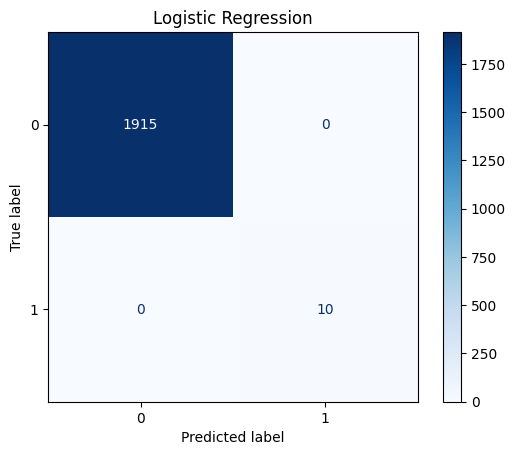


Classification Report:
                  precision    recall  f1-score   support

Not Bankrupt (0)       1.00      1.00      1.00      1915
    Bankrupt (1)       1.00      1.00      1.00        10

        accuracy                           1.00      1925
       macro avg       1.00      1.00      1.00      1925
    weighted avg       1.00      1.00      1.00      1925



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Generate Confusion Matrix
cm = confusion_matrix(y, y_pred_meta)

# Visualize Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Logistic Regression')
plt.show()

# Print Precision, Recall, F1-Score
print("\nClassification Report:")
print(classification_report(y, y_pred_meta, target_names=["Not Bankrupt (0)", "Bankrupt (1)"]))



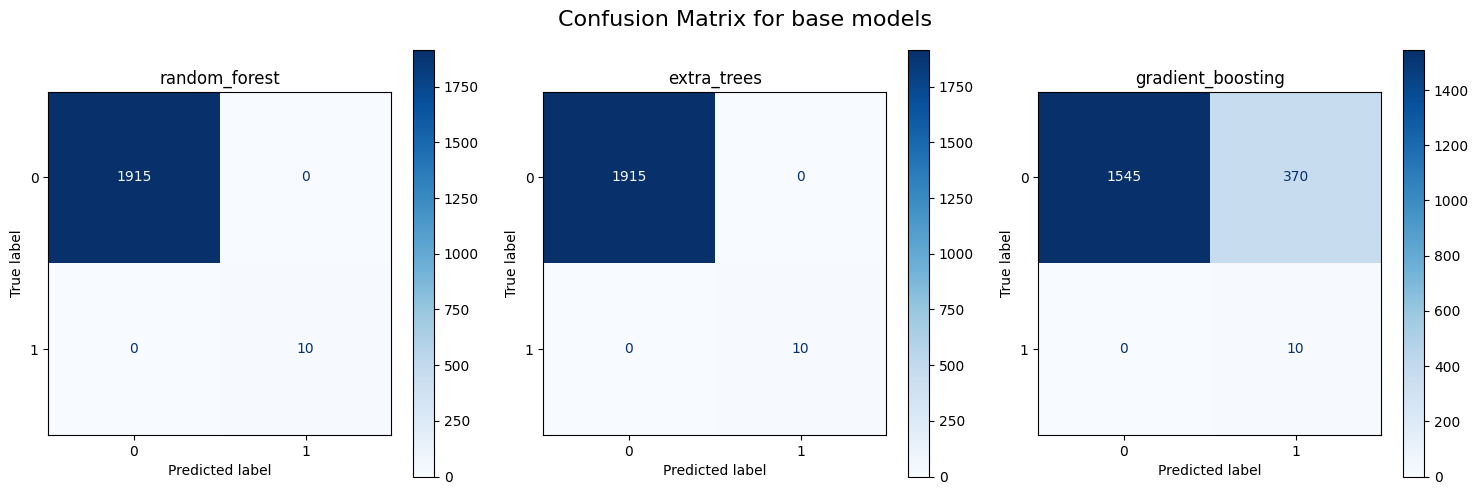

In [ ]:
# Generate Confusion Matrix for base models

num_cols = 3
num_rows = 1


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))  # Create subplots grid
axes = axes.flatten()  # Flatten the axes array for easier indexing
names=[item[0] for item in fitted_base_models]
for i in range(len(fitted_base_models)):
    name=names[i]

    cm = confusion_matrix(y, pred_base[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues',ax=axes[i])


    axes[i].set_title(f'{name}')

fig.suptitle('Confusion Matrix for base models', fontsize=16)
plt.tight_layout()
plt.show()

# Visualization of important feature

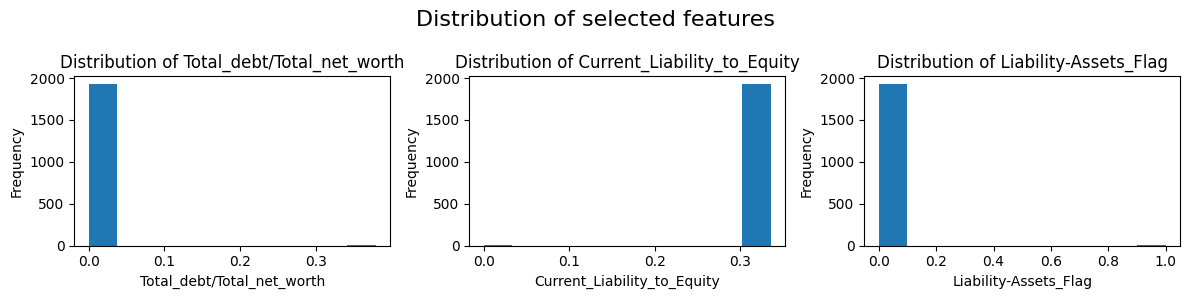

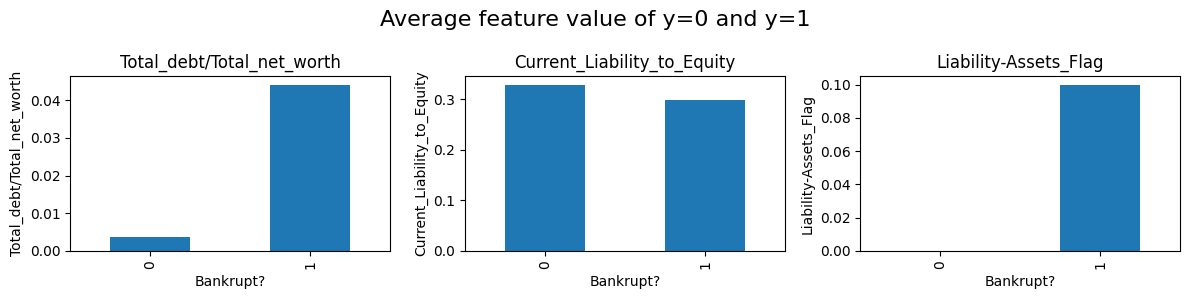

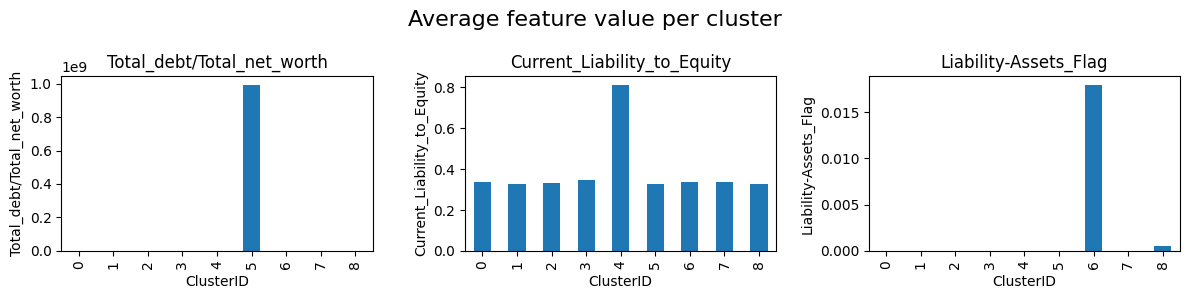

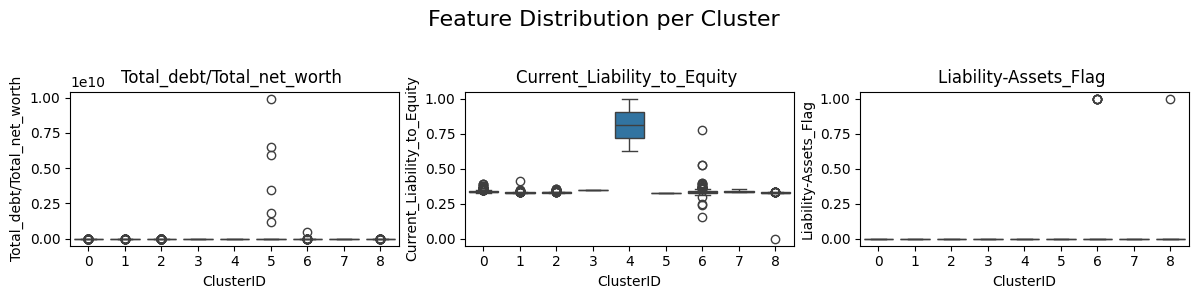

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np



def visualize():

    num_cols = len(selected_features)  # Number of columns in the subplot grid
    num_rows = 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))  # Create subplots grid

    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()  # Flatten the axes array for easier indexing
    for  i in range(len(selected_features)):
        feature=selected_features[i]
        # Plot histograms
        axes[i].hist(X[feature], bins=10)
        plt.tight_layout()
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')

    fig.suptitle('Distribution of selected features', fontsize=16)
    plt.tight_layout()

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))  # Create subplots grid

    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()  # Flatten the axes array for easier indexing
    for i, feature in enumerate(selected_features):
        feature_mean = subgroup_df.groupby('Bankrupt?')[feature].mean()

        feature_mean.plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'{feature}')
        axes[i].set_xlabel('Bankrupt?')
        axes[i].set_ylabel(feature)
    fig.suptitle('Average feature value of y=0 and y=1', fontsize=16)
    plt.tight_layout()

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    # axes = axes.flatten()

    for i, feature in enumerate(selected_features):

        mean_feature = df.groupby('ClusterID')[feature].mean()
        mean_feature.plot(kind='bar', ax=axes[i])  # Plot on the corresponding subplot
        axes[i].set_title(f'{feature}')
        axes[i].set_xlabel('ClusterID')
        axes[i].set_ylabel(feature)
    fig.suptitle('Average feature value per cluster', fontsize=16)
    plt.tight_layout()

    # Step 5: Plot boxplots for feature distributions across clusters using subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()

    for i, feature in enumerate(selected_features):
        sns.boxplot(x='ClusterID', y=feature, data=df, ax=axes[i])
        axes[i].set_title(f'{feature} ')
        axes[i].set_xlabel('ClusterID')
        axes[i].set_ylabel(feature)
    fig.suptitle('Feature Distribution per Cluster', fontsize=16)
    plt.tight_layout()
    plt.show()


visualize()